# Heart Rate Prediction Project
This notebook performs an analysis and prediction of heart rate using the Framingham dataset.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [4]:
# Load dataset
import pandas as pd
df = pd.read_csv("framingham.csv")

# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
# Checking for null values
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [6]:
# Filling missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify missing values
print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [ ]:
## Handling Missing Values
The dataset contained missing values in several features, including `education`, `cigsPerDay`, `BPMeds`, `totChol`, `BMI`, `heartRate`, and `glucose`.
To ensure data quality and prevent information loss, missing values were imputed using the median of each feature.
Median imputation was selected because it is robust to outliers and maintains the central tendency of the data without being heavily influenced by extreme values.
After preprocessing, all missing values were successfully removed, resulting in a complete dataset ready for exploratory data analysis and machine learning.

In [ ]:
# Basic statistics and visualization


In [7]:
#Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.0000,0.0,1.0000,1.0
age,4240.0,49.580189,8.572942,32.00,42.0000,49.0,56.0000,70.0
education,4240.0,1.979953,1.007087,1.00,1.0000,2.0,3.0000,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.0000,0.0,1.0000,1.0
cigsPerDay,4240.0,8.944340,11.904777,0.00,0.0000,0.0,20.0000,70.0
BPMeds,4240.0,0.029245,0.168513,0.00,0.0000,0.0,0.0000,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.0000,0.0,0.0000,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.0000,0.0,1.0000,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.0000,0.0,0.0000,1.0
totChol,4240.0,236.667689,44.328480,107.00,206.0000,234.0,262.0000,696.0


In [8]:
# Dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Data types
df.dtypes

Number of Rows: 4240
Number of Columns: 16


male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [9]:
# Distribution of the target variable
print(df['TenYearCHD'].value_counts())
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

TenYearCHD
0    3596
1     644
Name: count, dtype: int64
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


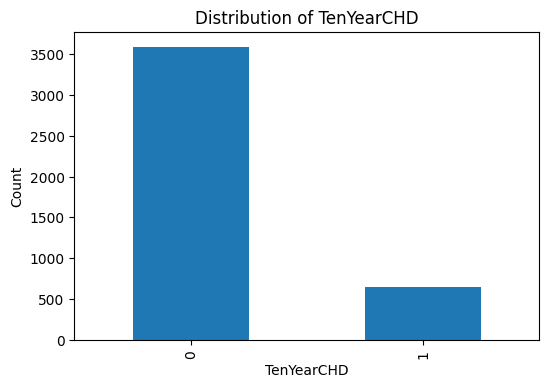

In [21]:
#bar chart
plt.figure(figsize=(6,4))
df['TenYearCHD'].value_counts().plot(kind='bar')
plt.title('Distribution of TenYearCHD')
plt.xlabel('TenYearCHD')
plt.ylabel('Count')
plt.show()

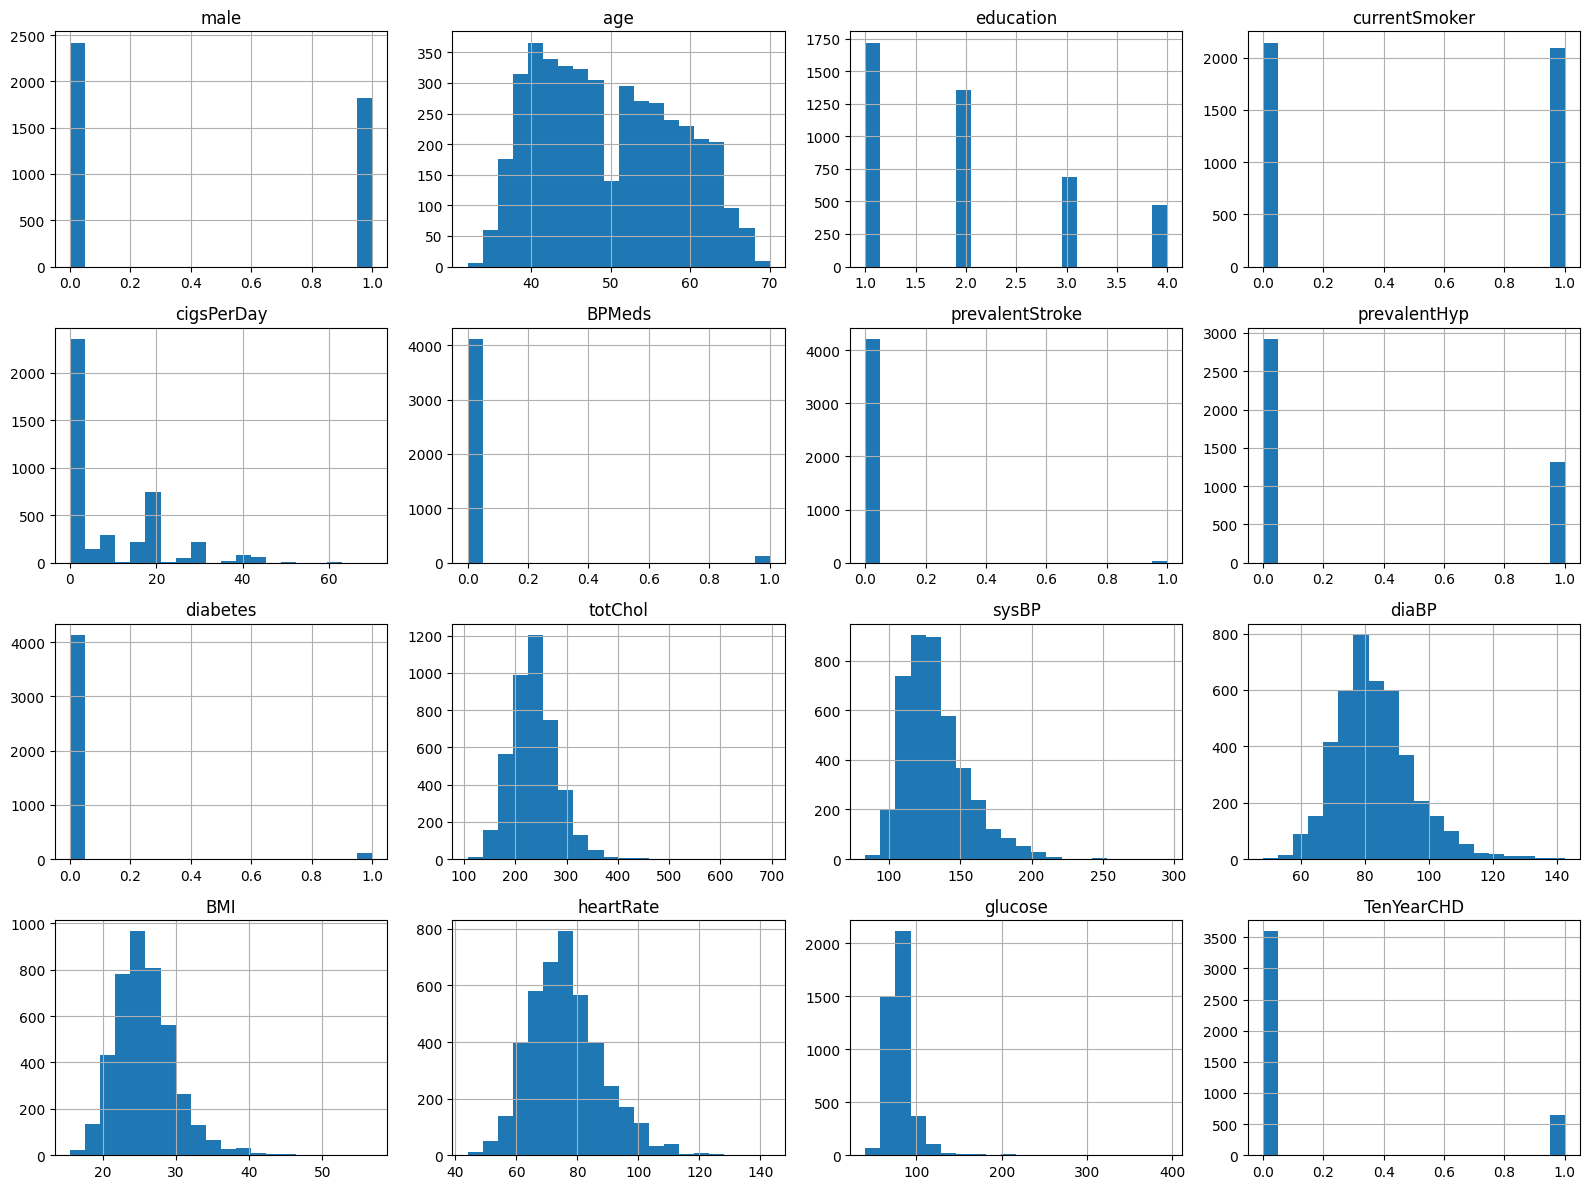

In [9]:
#  Histograms
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

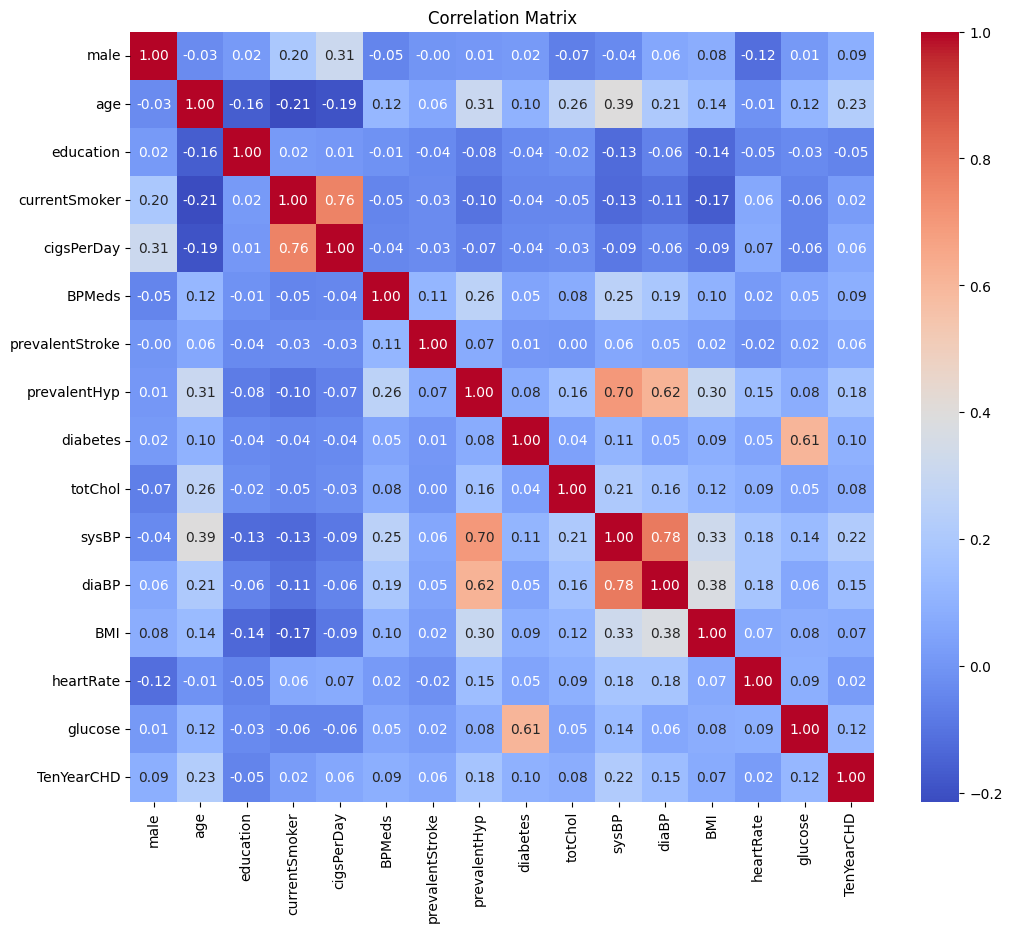

In [22]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

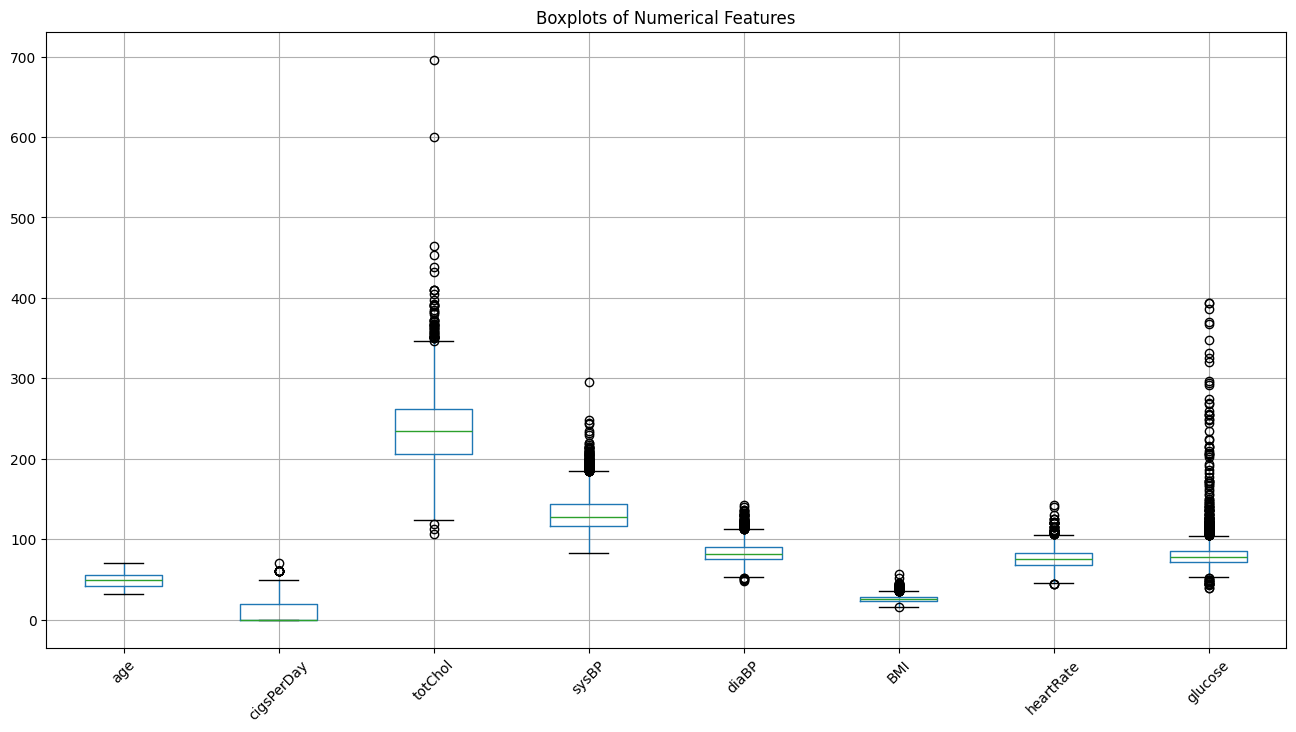

In [29]:
#Boxplots for Outlier Detection
numerical_features = [
    'age', 'cigsPerDay', 'totChol',
    'sysBP', 'diaBP', 'BMI',
    'heartRate', 'glucose'
]

plt.figure(figsize=(16,8))
df[numerical_features].boxplot(rot=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [ ]:
## Basic Statistics and Visualization
After preprocessing, exploratory data analysis (EDA) was performed to understand the dataset better.
Summary statistics were generated to examine the distribution, central tendency, and variability of each feature.
Visualizations including histograms, boxplots, and a correlation heatmap were used to identify feature distributions, detect potential outliers, and explore relationships among variables. 
Additionally, the distribution of the target variable (`TenYearCHD`) was examined to assess class balance before training machine learning models.
These analyses provided valuable insights into the characteristics of the Framingham dataset and informed subsequent feature selection and model development.

In [12]:
# DEFINE FEATURES AND TARGET
# Features (independent variables)
X = df.drop('TenYearCHD', axis=1)

# Target (dependent variable)
y = df['TenYearCHD']

# Display their shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4240, 15)
Target shape: (4240,)


In [13]:
#Display the feature names
print("Features:")
print(X.columns.tolist())

Features:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [ ]:
## Feature and Target Selection
The dataset was divided into independent variables (features) and the dependent variable (target).
The TenYearCHD column, which indicates whether a patient is at risk of developing coronary heart disease within the next ten years, was selected as the target variable (`y`).
The remaining 15 clinical and demographic variables were used as input features (`X`) for training and evaluating the machine learning models.

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the datasets
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (3392, 15)
Testing Features : (848, 15)
Training Labels  : (3392,)
Testing Labels   : (848,)


In [ ]:
## Train-Test Split
The dataset was divided into training and testing sets using an 80:20 ratio. 
The training set was used to train the machine learning models, while the testing set was reserved for evaluating their performance on unseen data.
A fixed `random_state` of 42 was used to ensure reproducibility of the results.
Additionally, the `stratify` parameter was set to the target variable (`TenYearCHD`) to preserve the original class distribution in both the training and testing datasets, resulting in a more reliable evaluation.

In [24]:
# Scaling
scaler = StandardScaler()

# Fit on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify the scaled data shapes
print("Scaled Training Features:", X_train_scaled.shape)
print("Scaled Testing Features :", X_test_scaled.shape)

Scaled Training Features: (3392, 15)
Scaled Testing Features : (848, 15)


In [ ]:
## Feature Scaling
Feature scaling was performed using the `StandardScaler` from Scikit-learn.
This method standardizes each feature by removing its mean and scaling it to unit variance.
The scaler was fitted only to the training data to prevent data leakage, and the same transformation was then applied to the testing data.
Standardization is particularly important for machine learning algorithms such as Logistic Regression, Support Vector Machines (SVM), and K-Nearest Neighbors (KNN), as they are sensitive to differences in feature scales.

In [26]:
# MODEL TRAINING 
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

# Train all models
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
K-Nearest Neighbors trained successfully.
Support Vector Machine trained successfully.


In [ ]:
## Model Training
Five supervised machine learning algorithms were trained to predict the 10-year risk of coronary heart disease (CHD):
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
Each model was trained using the standardized training dataset.
Training multiple algorithms enables comparison of their predictive performance and helps identify the most suitable model for cardiovascular risk prediction.

In [17]:
# Predictions

predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_scaled)
    print(f"{name} predictions completed.")

Logistic Regression predictions completed.
Decision Tree predictions completed.
Random Forest predictions completed.
K-Nearest Neighbors predictions completed.
Support Vector Machine predictions completed.


In [18]:
# Example: First 10 predictions from each model
for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(y_pred[:10])


Logistic Regression
[0 0 0 0 0 0 0 0 0 0]

Decision Tree
[0 1 0 0 0 0 0 1 0 1]

Random Forest
[0 0 0 0 0 0 0 0 0 0]

K-Nearest Neighbors
[0 0 0 0 0 0 0 0 0 0]

Support Vector Machine
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
## Model Predictions
After training, each machine learning model was used to generate predictions on the unseen testing dataset.
These predictions represent whether a patient is predicted to develop coronary heart disease (CHD) within the next ten years.
The predicted labels were stored for each model and used in the subsequent evaluation phase to compare their classification performance using metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

In [27]:
# EVALUATION METRICS

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = []

for name, model in trained_models.items():
    y_pred = predictions[name]

    # Predict probabilities (or decision scores) for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Display results sorted by Accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Support Vector Machine,0.850236,0.750000,0.023256,0.045113,0.552458
2,Random Forest,0.845519,0.428571,0.046512,0.083916,0.642020
0,Logistic Regression,0.844340,0.411765,0.054264,0.095890,0.702192
3,K-Nearest Neighbors,0.839623,0.400000,0.108527,0.170732,0.579018
1,Decision Tree,0.750000,0.197080,0.209302,0.203008,0.528156


In [19]:
# CLASSIFICATION REPORT

# Classification report for each model
for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print('='*60)
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848


Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       719
           1       0.20      0.21      0.20       129

    accuracy                           0.75       848
   macro avg       0.53      0.53      0.53       848
weighted avg       0.76      0.75      0.75       848


Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.43      0.05      0.08       129

    accuracy                           0.85       848
   macro avg       0.64      0.52      0.50       848
weighted avg       0.79

<Figure size 500x400 with 0 Axes>

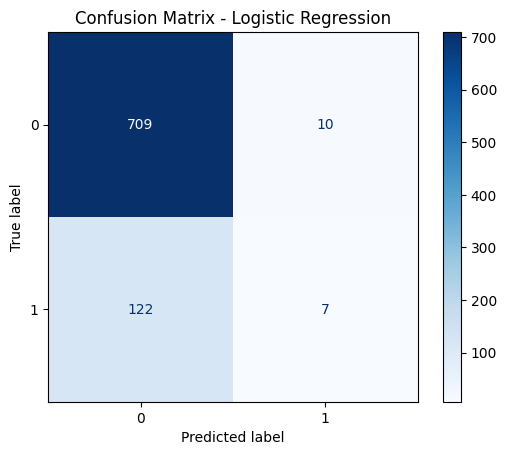

<Figure size 500x400 with 0 Axes>

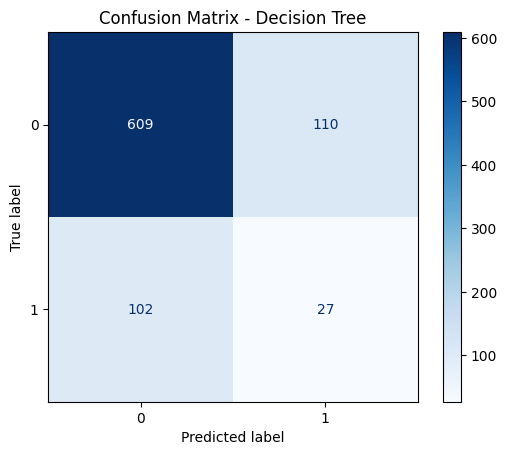

<Figure size 500x400 with 0 Axes>

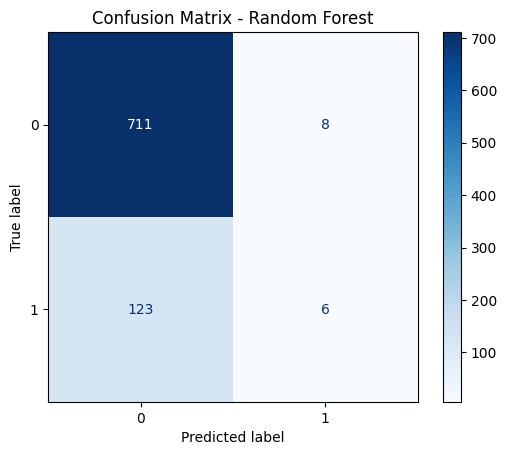

<Figure size 500x400 with 0 Axes>

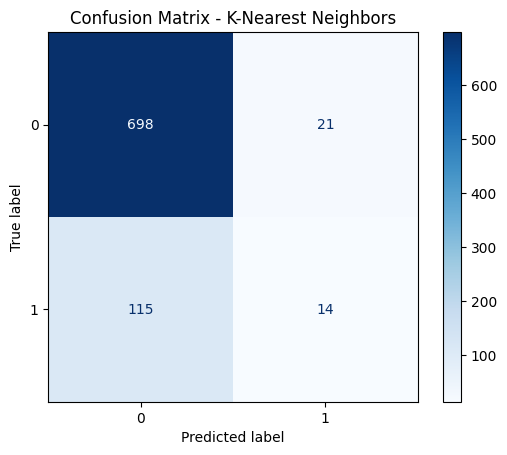

<Figure size 500x400 with 0 Axes>

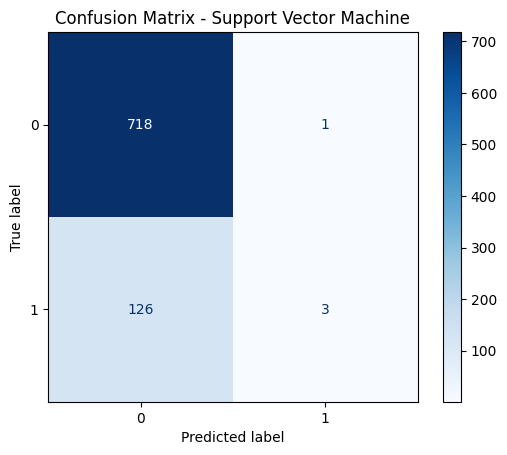

In [28]:
for name, model in trained_models.items():
    plt.figure(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [ ]:
## Model Evaluation
The performance of each machine learning model was evaluated using several standard classification metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a comprehensive assessment of each model's predictive capability for identifying individuals at risk of developing coronary heart disease.

Additionally, confusion matrices and classification reports were generated to examine the distribution of true positives, true negatives, false positives, and false negatives. Comparing multiple evaluation metrics allowed for the selection of the most effective model for this binary classification problem.

In [ ]:
## COCLUSION
In this project, a machine learning pipeline was developed to predict the 10-year risk of coronary heart disease (CHD) using the Framingham Heart Study dataset. The workflow included data preprocessing, missing value imputation, exploratory data analysis (EDA), feature scaling, model training, prediction, and performance evaluation.
Five supervised machine learning algorithms—Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM)—were trained and evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
Comparing multiple models provided a comprehensive assessment of their predictive performance and helped identify the most suitable approach for cardiovascular risk prediction.
The project demonstrates the importance of proper data preprocessing and model evaluation in developing reliable healthcare prediction systems. Machine learning techniques can assist healthcare professionals by identifying individuals at higher risk of developing coronary heart disease, enabling earlier intervention and more informed clinical decision-making.
## Future Work
Future improvements to this project may include:
- Hyperparameter tuning using Grid Search or Randomized Search to improve model performance.
- Addressing class imbalance using techniques such as SMOTE or class weighting.
- Performing feature selection or feature engineering to reduce redundancy and improve predictive accuracy.
- Exploring advanced ensemble methods such as XGBoost, LightGBM, or CatBoost.
- Deploying the best-performing model as a web application or API for real-time cardiovascular risk prediction.